<a href="https://colab.research.google.com/github/mwakitrevor146-prog/online-retail-analytics/blob/main/EDA_RFM_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#install libraries

In [ ]:
!pip install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Install mlxtend for association rule mining
!pip install mlxtend

In [ ]:
#dowwnload dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vijayuv/onlineretail")

print("Path to dataset files:", path)

100%|██████████| 7.20M/7.20M [00:00<00:00, 83.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vijayuv/onlineretail/versions/1


In [ ]:
#check files inside the dataset
import os

os.listdir(path)

['OnlineRetail.csv']

In [ ]:
#loading the dataset
df = pd.read_csv(path + "/OnlineRetail.csv", encoding='latin1')

In [ ]:
#inspection
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.shape

(541909, 8)

In [ ]:
#check missing values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
#duplicate rows
df.duplicated().sum()

np.int64(5268)

In [ ]:
#conversion of date time properly
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [ ]:
#negative values
(df['Quantity'] < 0).sum()
(df['UnitPrice'] < 0).sum()

np.int64(2)

In [ ]:
#summary statistics
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
#findings were | Column      | Missing Values |
#| ----------- | -------------- |
#| Description | 1,454          |
#| CustomerID  | 135,080        |

#missing customer id meant anonymity or non registered customers
#missing description rows maybe incomplete product records
# duplicate rows were 5268
#quantity having negative values means there were refunds ,cancellations
#unit price negative value shows adjustment on price

In [ ]:
#cleaning the data
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

In [ ]:
#handle missing values
df = df.dropna(subset=['Description'])

In [ ]:
df = df.dropna(subset=['CustomerID'])

In [ ]:
#remove zero/negative quantities
# remove zero/negative prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [ ]:
#verify cleaned dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.492832,NaN,22.241836,1713.539549


In [ ]:
df.shape

(392692, 8)

In [ ]:
#create revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Duplicate records were removed to maintain dataset integrity. Missing customer identifiers and product descriptions were excluded to improve analytical reliability. Records containing non-positive quantities or unit prices were treated as invalid or return transactions and removed for the purpose of sales analysis.

# Exploratory Data Analysis (EDA)
This section explores trends, patterns, and relationships within the online retail dataset using statistical analysis and visualizations.

## Summary Statistics
Basic statistical analysis was performed to understand the distribution of numerical variables such as quantity, unit price, and revenue.

In [ ]:
df[['Quantity', 'UnitPrice', 'Revenue']].describe()

,Quantity,UnitPrice,Revenue
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


top countries by revenue

In [ ]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

top_countries

,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


visualization

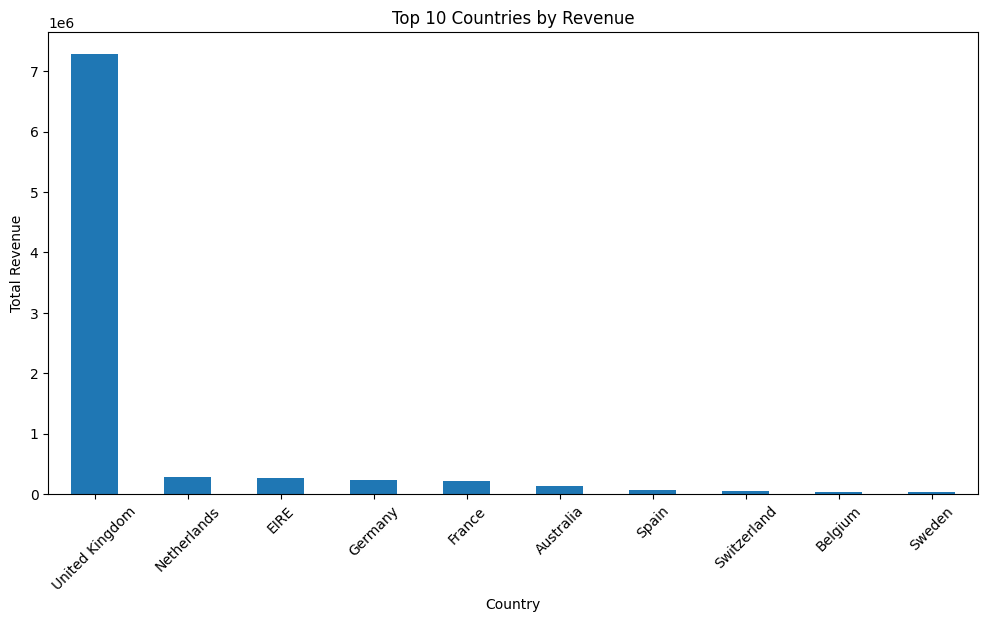

In [ ]:
plt.figure(figsize=(12,6))

top_countries.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.show()

### Observation
The United Kingdom contributes the highest revenue, indicating that the business is heavily concentrated in the UK market.

monthly sales

In [ ]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [ ]:
#monthly revenue
monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales

,Revenue
Month,
2010-12,570422.730
2011-01,568101.310
2011-02,446084.920
2011-03,594081.760
2011-04,468374.331
2011-05,677355.150
2011-06,660046.050
2011-07,598962.901
2011-08,644051.040


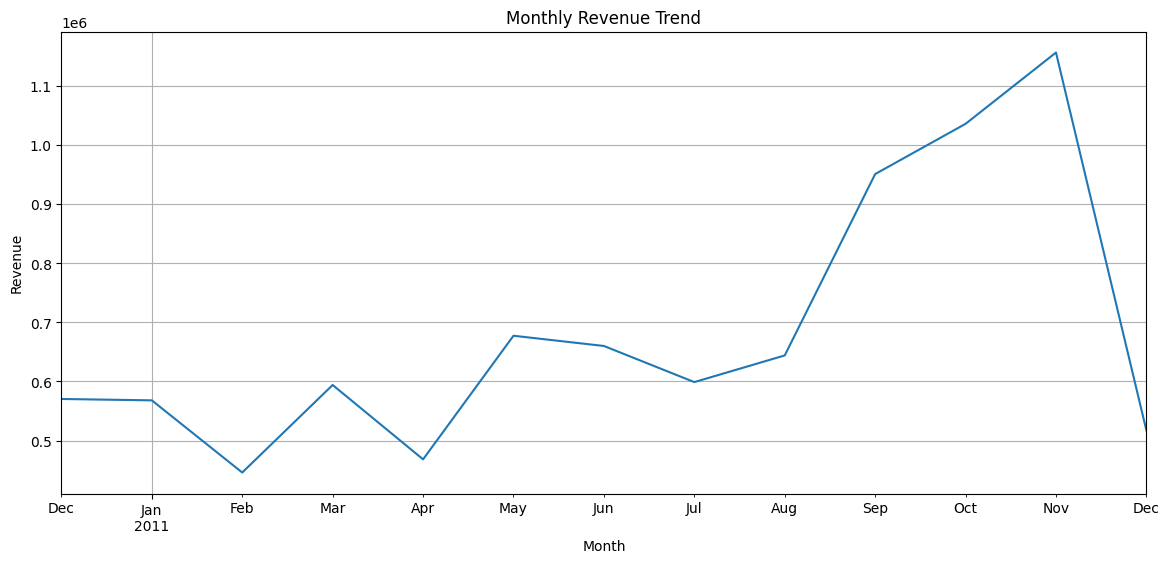

In [ ]:
plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.grid(True)

plt.show()

### Observation
Monthly revenue trends reveal periods of high and low sales activity, helping identify seasonality and business performance patterns over time.

In [ ]:
#best selling products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


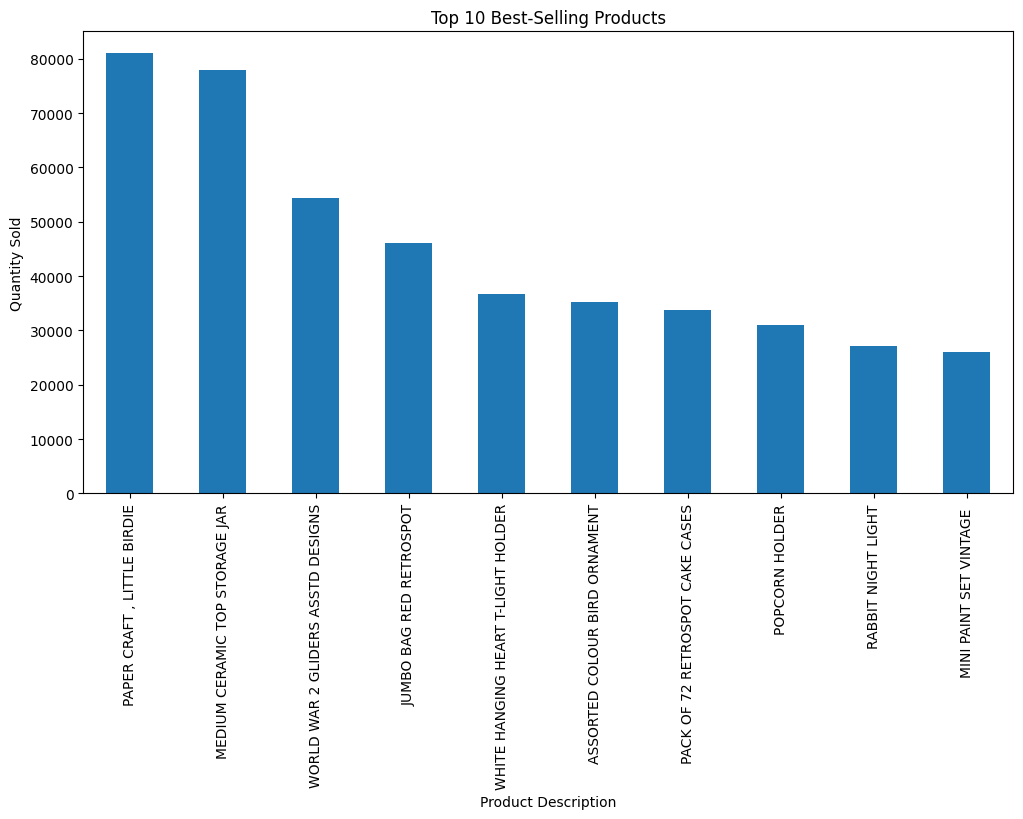

In [ ]:
#visualization
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Product Description')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=90)

plt.show()

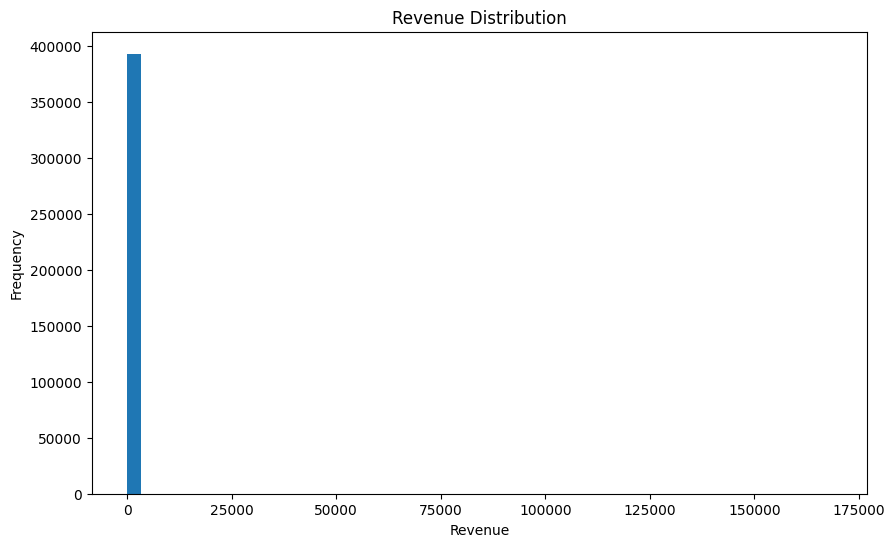

In [ ]:
#skewness and outliers
#revenue distribution
plt.figure(figsize=(10,6))

plt.hist(df['Revenue'], bins=50)

plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

plt.show()

In [ ]:
#top customers by revenue
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

top_customers

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


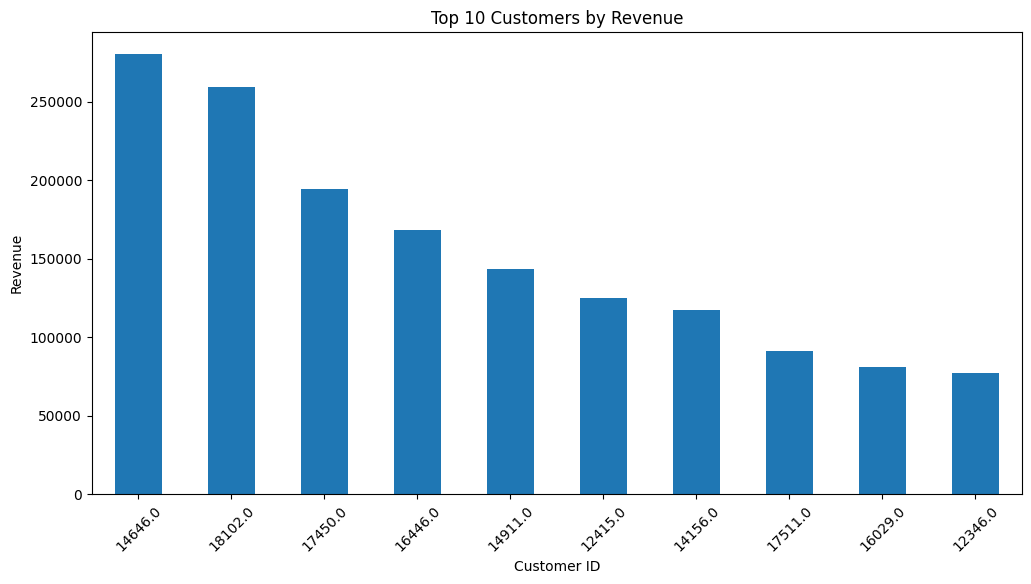

In [ ]:
plt.figure(figsize=(12,6))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

In [ ]:
#rfm
import pandas as pd

reference_date = df['InvoiceDate'].max()
reference_date

Timestamp('2011-12-09 12:50:00')

In [ ]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'count',                                      # Frequency
    'Revenue': 'sum'                                           # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


In [ ]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

In [ ]:
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1,2,3,4,5])

In [ ]:
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [ ]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,325,1,77183.60,1,1,5,115
12347.0,1,182,4310.00,5,5,5,555
12348.0,74,31,1797.24,2,3,4,234
12349.0,18,73,1757.55,4,4,4,444
12350.0,309,17,334.40,1,2,2,122


In [ ]:
#classify behaviour
def segment(row):
    if row['RFM_Score'] == '555':
        return 'Champions'
    elif row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Loyal Customers'
    elif row['R_score'] <= 2:
        return 'At Risk'
    elif row['F_score'] == 1:
        return 'New Customers'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)

rfm['Segment'].value_counts()

,count
Segment,
At Risk,1511
Others,1150
Loyal Customers,1063
Champions,309
New Customers,305


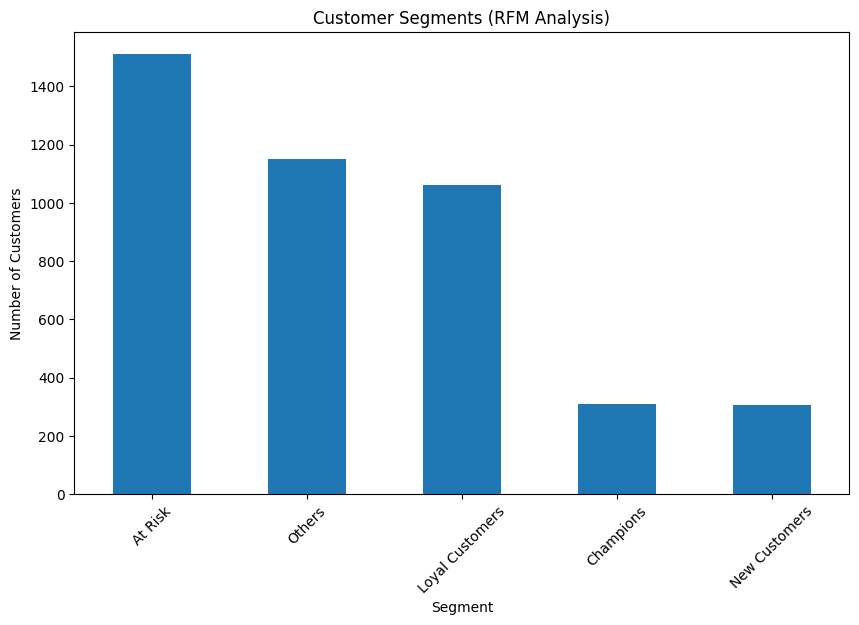

In [ ]:
import matplotlib.pyplot as plt

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10,6))
segment_counts.plot(kind='bar')

plt.title('Customer Segments (RFM Analysis)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)
plt.show()

## RFM Insights

- **Champions**: High-value customers who buy frequently and recently
- **Loyal Customers**: Regular buyers contributing steady revenue
- **At Risk**: Previously active customers who have stopped buying recently
- **New Customers**: First-time or low-frequency buyers
- **Others**: Mixed or low engagement customers

### Business Value:
- Retain Champions with exclusive offers
- Reactivate At-Risk customers
- Convert New Customers into Loyal Customers